# 🔮 Step 5 — Prediction (Inference)

**Protein Function Prediction Using Genomic Language Model (ESM-2)**

Run the trained model on **new, raw protein sequences** to predict GO terms with confidence scores.

---

### Output
| File | Description |
|------|-------------|
| `results/metrics/predictions.json` | Predictions for input sequences |
| `results/plots/prediction_confidence.png` | Confidence bar charts |

In [1]:
import os, json, pickle
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt

# ─── Configuration ───
PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
MODELS_DIR = os.path.join(PROJECT_ROOT, 'results', 'models')
METRICS_DIR = os.path.join(PROJECT_ROOT, 'results', 'metrics')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'plots')

ESM_MODEL_NAME = 'facebook/esm2_t6_8M_UR50D'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
COLORS = ['#00D4FF', '#FF6B6B', '#4ECDC4', '#FFE66D', '#A855F7', '#F97316', '#06B6D4', '#EC4899']
print(f'🖥️  Device: {DEVICE}')

🖥️  Device: cpu


## 5.1 — Load Model & ESM-2

In [2]:
# Model classes (inline)
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.skip = (in_dim == out_dim)
        self.block = nn.Sequential(nn.Linear(in_dim, out_dim), nn.BatchNorm1d(out_dim), nn.GELU(), nn.Dropout(dropout))
    def forward(self, x):
        out = self.block(x)
        return out + x if self.skip else out

class ProteinFunctionClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_labels, dropout=0.3):
        super().__init__()
        layers = []; prev = input_dim
        for h in hidden_dims: layers.append(ResidualBlock(prev, h, dropout)); prev = h
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(prev, num_labels)
    def forward(self, x): return self.classifier(self.features(x))
    def predict_proba(self, x): return torch.sigmoid(self.forward(x))

# Load ESM-2
print('📥 Loading ESM-2...')
tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL_NAME)
esm_model = AutoModel.from_pretrained(ESM_MODEL_NAME).to(DEVICE).eval()

# Load classifier
ckpt = torch.load(os.path.join(MODELS_DIR, 'best_model.pt'), map_location=DEVICE, weights_only=False)
cfg = ckpt['config']
model = ProteinFunctionClassifier(cfg['input_dim'], cfg['hidden_dims'], cfg['num_labels'], cfg['dropout']).to(DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# Load label binarizer
with open(os.path.join(PROCESSED_DIR, 'label_binarizer.pkl'), 'rb') as f:
    mlb = pickle.load(f)
go_terms = mlb.classes_

print(f'✅ Models loaded ({cfg["num_labels"]} GO classes)')

📥 Loading ESM-2...


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Models loaded (4 GO classes)


## 5.2 — Predict GO Terms for New Sequences

In [3]:
def predict_sequence(sequence, name='Query', threshold=0.3, top_k=10):
    """
    Predict GO terms for a raw protein sequence.
    Returns a dictionary with predictions sorted by confidence.
    """
    # Create ESM-2 embedding
    encoded = tokenizer(sequence, return_tensors='pt', padding=True,
                        truncation=True, max_length=1022)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        hidden = esm_model(**encoded).last_hidden_state
    mask = encoded['attention_mask'].unsqueeze(-1)
    embedding = ((hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9))

    # Classify
    with torch.no_grad():
        probs = model.predict_proba(embedding).cpu().numpy()[0]

    # Gather results
    results = sorted(
        [(go_terms[i], float(probs[i])) for i in range(len(go_terms))],
        key=lambda x: x[1], reverse=True
    )[:top_k]

    above_thresh = [(go, p) for go, p in results if p >= threshold]
    
    return {'name': name, 'length': len(sequence),
            'predictions': [{'go_term': g, 'confidence': round(p, 4)} for g, p in results],
            'above_threshold': len(above_thresh)}

print('✅ Prediction function ready')

✅ Prediction function ready


## 5.3 — Example Predictions

In [4]:
# Example proteins
examples = {
    'Hemoglobin β': 'MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH',
    'GFP': 'MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITLGMDELYK',
    'Insulin': 'MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKTRREAEDLQVGQVELGGGPGAGSLQPLALEGSLQKRGIVEQCCTSICSLYQLENYCN',
}

all_preds = []
for name, seq in examples.items():
    result = predict_sequence(seq, name)
    all_preds.append(result)
    print(f'\n🧬 {name} ({len(seq)} aa) — {result["above_threshold"]} predictions above 0.3:')
    for p in result['predictions'][:5]:
        bar = '█' * int(p['confidence'] * 30)
        print(f'   {p["go_term"]}  {p["confidence"]:.4f}  {bar}')

# Save predictions
pred_path = os.path.join(METRICS_DIR, 'predictions.json')
with open(pred_path, 'w') as f:
    json.dump(all_preds, f, indent=2)
print(f'\n💾 Predictions → {pred_path}')


🧬 Hemoglobin β (147 aa) — 4 predictions above 0.3:
   GO:0005829  0.5602  ████████████████
   GO:0005737  0.5248  ███████████████
   GO:0005886  0.5114  ███████████████
   GO:0005634  0.4695  ██████████████

🧬 GFP (238 aa) — 4 predictions above 0.3:
   GO:0005829  0.5404  ████████████████
   GO:0005737  0.5184  ███████████████
   GO:0005886  0.5059  ███████████████
   GO:0005634  0.4647  █████████████

🧬 Insulin (110 aa) — 4 predictions above 0.3:
   GO:0005829  0.5323  ███████████████
   GO:0005886  0.5144  ███████████████
   GO:0005737  0.5031  ███████████████
   GO:0005634  0.4614  █████████████

💾 Predictions → c:\Users\chowd\OneDrive\Desktop\Work_ML\protein_function_prediction\results\metrics\predictions.json


## 5.4 — 📈 Prediction Confidence Chart

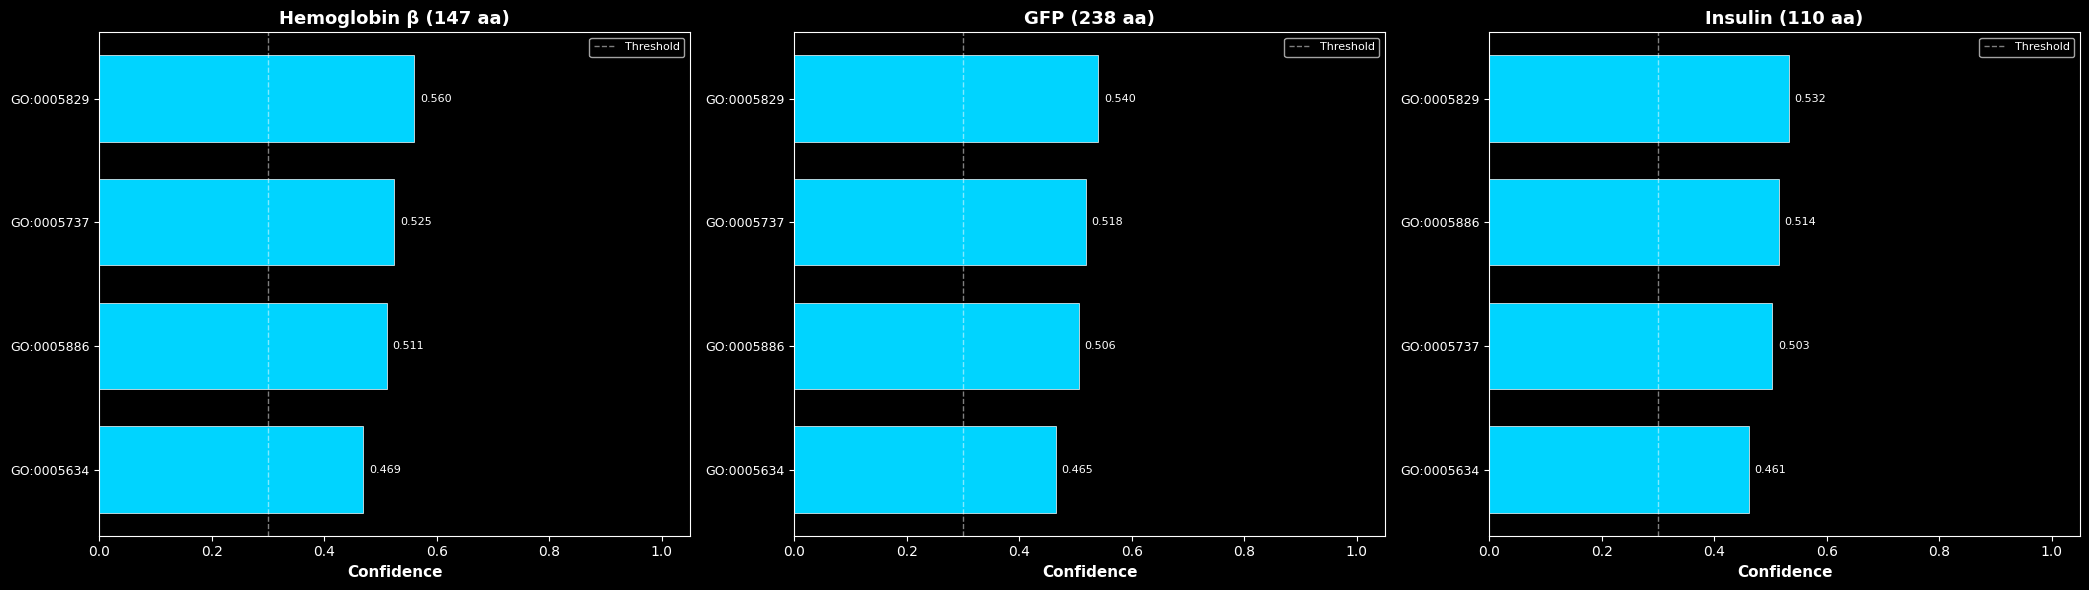

✅ Prediction confidence chart saved!


In [5]:
n_examples = len(all_preds)
fig, axes = plt.subplots(1, n_examples, figsize=(7 * n_examples, 6))
if n_examples == 1: axes = [axes]

for ax, pred in zip(axes, all_preds):
    preds = pred['predictions'][:8]
    terms = [p['go_term'] for p in preds]
    confs = [p['confidence'] for p in preds]
    bar_colors = [COLORS[0] if c >= 0.3 else COLORS[1] for c in confs]
    ax.barh(range(len(terms)), confs, color=bar_colors, edgecolor='white', lw=0.5, height=0.7)
    ax.set_yticks(range(len(terms))); ax.set_yticklabels(terms, fontsize=9)
    ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
    ax.set_title(f'{pred["name"]} ({pred["length"]} aa)', fontsize=13, fontweight='bold')
    ax.axvline(0.3, color='white', ls='--', lw=1, alpha=0.5, label='Threshold')
    ax.set_xlim([0, 1.05]); ax.invert_yaxis(); ax.legend(fontsize=8)
    for i, v in enumerate(confs):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'prediction_confidence.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Prediction confidence chart saved!')

## 5.5 — 🔬 Try Your Own Sequence

In [6]:
# Paste your protein sequence below:
USER_SEQUENCE = 'PASTE_YOUR_SEQUENCE_HERE'

if USER_SEQUENCE != 'PASTE_YOUR_SEQUENCE_HERE':
    result = predict_sequence(USER_SEQUENCE, 'User Sequence')
    print(f'🧬 Predictions for your sequence ({result["length"]} aa):')
    for p in result['predictions']:
        print(f'   {p["go_term"]}  {p["confidence"]:.4f}')
else:
    print('ℹ️  Replace PASTE_YOUR_SEQUENCE_HERE with an amino acid sequence to predict its function.')

ℹ️  Replace PASTE_YOUR_SEQUENCE_HERE with an amino acid sequence to predict its function.


---
### ✅ Prediction Complete!
**Next →** Open `06_visualize.ipynb` for advanced embedding visualizations.